# Finite temperature algorithm 

In this example we use the [pyALF](https://github.com/ALF-QMC/pyALF) interface to run ALF's finite temperature algorithm with the Mz choice of Hubbard Stratonovich transformation on a 4-site ring.

The finite temperature approach is the method of choice if  one is interested in excited-state properties. The finite temperature expectation value of  any  observable  $\hat{O}$ can then be computed by:
$$
	 \langle\hat{O}\rangle=\frac{\operatorname{Tr}\left[e^{-\beta \hat{H}} \hat{O}\right]}{\operatorname{Tr}\left[e^{-\beta \hat{H}}\right]} ,
$$
where $\beta=1/k_B T$ is the inverse temperature. For further details, see Sec. 2 of [ALF documentation](https://alf-qmc.de/doc.pdf).

---

**1.** Import `Simulation` class from the `py_alf` python module, which provides the interface with ALF, as well as numerical and plotting packages:

In [1]:
import matplotlib.pyplot as plt  # Plotting library

#
import numpy as np  # Numerical library

from py_alf import ALF_source, Simulation  # Interface with ALF

alf_src = ALF_source(branch='main')    # Obtain ALF source code

Checking out branch main
Your branch is up to date with 'origin/main'.


Already on 'main'


 **2.** Create instances of `Simulation`, specifying the necessary parameters, in particular the `Projector` to `False`:

In [2]:
sims = []                                # Vector of Simulation instances
print('Beta values used:')
for beta in [0.5, 1, 1.5, 3, 5, 10]:               # Values of Beta
    print(beta)
    sim = Simulation(
        alf_src,
        'Hubbard',                       # Hamiltonian
        {                                # Model and simulation parameters for each Simulation instance
        'Model': 'Hubbard',              #    Base model
        'Lattice_type': 'N_leg_ladder',  #    Lattice type
        'L1': 4,                         #    Lattice length in the first unit vector direction
        'L2': 1,                         #    Lattice length in the second unit vector direction
        'Checkerboard': False,           #    Whether checkerboard decomposition is used or not
        'Symm': True,                    #    Whether symmetrization takes place
        'Projector': False,               #    Whether to use the projective algorithm
        'ham_T': 1.0,                    #    Hopping parameter
        'ham_U': 4.0,                    #    Hubbard interaction
        'ham_Tperp': 0.0,                #    For bilayer systems
        'beta': beta,                     #    Inverse temperature
        'Ltau': 0,                       #    '1' for time-displaced Green functions; '0' otherwise
        'NSweep': 600,                   #    Number of sweeps per bin
        'NBin': 50,                      #    Number of bins
        'Dtau': 0.05,                    #    Ltrot=beta/Dtau
        'Mz': True,                      #    If true, sets the M_z-Hubbard model: Nf=2, N_sum=1,
        },                               #             HS field couples to z-component of magnetization
    )
    sims.append(sim)

Beta values used:
0.5
1
1.5
3
5
10


**3.** Compile ALF, this may take a few minutes:

In [ ]:
sims[0].compile()                        # Compilation needs to be performed only once

Compiling ALF... 
Cleaning up Prog/
Cleaning up Libraries/
Cleaning up Analysis/
Compiling Libraries


entanglement_mod.F90:35:2:

   35 | #warning "You are compiling entanglement without MPI. No results possible"
      |  1~~~~~~
ar: creating modules_90.a
ar: creating libqrref.a


Compiling Analysis
Compiling Program
Parsing Hamiltonian parameters
filename: Hamiltonians/Hamiltonian_Kondo_smod.F90
filename: Hamiltonians/Hamiltonian_Hubbard_smod.F90
filename: Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_smod.F90
filename: Hamiltonians/Hamiltonian_tV_smod.F90
filename: Hamiltonians/Hamiltonian_LRC_smod.F90
filename: Hamiltonians/Hamiltonian_Z2_Matter_smod.F90
Compiling program modules
Link program
Done.


**4.** Perform the simulations, as specified in each element of `sim`:

In [7]:
for sim in sims:
    sim.run()   # Perform the actual simulation in ALF

Prepare directory "/Users/indra/Downloads/ALF_data/Hubbard_N_leg_ladder_L1=4_L2=1_Checkerboard=False_Symm=True_Projector=False_T=1.0_U=4.0_Tperp=0.0_beta=0.5_Dtau=0.05_Mz=True" for Monte Carlo run.
Run /Users/indra/Documents/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
 No initial configuration


 Setting N_FL = 2 since this is mandatory for Mz-Hubbard model


Prepare directory "/Users/indra/Downloads/ALF_data/Hubbard_N_leg_ladder_L1=4_L2=1_Checkerboard=False_Symm=True_Projector=False_T=1.0_U=4.0_Tperp=0.0_beta=1_Dtau=0.05_Mz=True" for Monte Carlo run.
Create new directory.
Run /Users/indra/Documents/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
 No initial configuration


 Setting N_FL = 2 since this is mandatory for Mz-Hubbard model


Prepare directory "/Users/indra/Downloads/ALF_data/Hubbard_N_leg_ladder_L1=4_L2=1_Checkerboard=False_Symm=True_Projector=False_T=1.0_U=4.0_Tperp=0.0_beta=1.5_Dtau=0.05_Mz=True" for Monte Carlo run.
Create new directory.
Run /Users/indra/Documents/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
 No initial configuration


...

 Setting N_FL = 2 since this is mandatory for Mz-Hubbard model


Prepare directory "/Users/indra/Downloads/ALF_data/Hubbard_N_leg_ladder_L1=4_L2=1_Checkerboard=False_Symm=True_Projector=False_T=1.0_U=4.0_Tperp=0.0_beta=5_Dtau=0.05_Mz=True" for Monte Carlo run.
Create new directory.
Run /Users/indra/Documents/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
 No initial configuration


 Setting N_FL = 2 since this is mandatory for Mz-Hubbard model


Prepare directory "/Users/indra/Downloads/ALF_data/Hubbard_N_leg_ladder_L1=4_L2=1_Checkerboard=False_Symm=True_Projector=False_T=1.0_U=4.0_Tperp=0.0_beta=10_Dtau=0.05_Mz=True" for Monte Carlo run.
Create new directory.
Run /Users/indra/Documents/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
 No initial configuration


 Setting N_FL = 2 since this is mandatory for Mz-Hubbard model


**5.** Calculate the internal energies:

In [8]:
%%capture
ener = np.empty((len(sims), 2))          # Matrix for storing energy values
betas = np.empty((len(sims),))          # Matrix for betas values, for plotting
for i, sim in enumerate(sims):
    print(sim.sim_dir)                   # Directory containing the simulation output
    sim.analysis()                       # Perform default analysis
    betas[i] = sim.sim_dict['beta']                        # Store beta value
    obs = sim.get_obs()
    ener[i] = obs.iloc[0][['Ener_scal0', 'Ener_scal0_err']]  # Store energy value

Where the _cell magic_ `%%capture` suppresses the output of `sim.analysis()`, which lists the data directories and observables.

In [5]:
print('For beta values', betas, 'the measured energies are:\n', ener)

For beta values [ 0.5  1.   1.5  3.   5.  10. ] the measured energies are:
 [[ 0.73546061  0.00200781]
 [-0.62449636  0.00262793]
 [-1.1740427   0.00381899]
 [-1.78632345  0.00453947]
 [-1.97154912  0.00657653]
 [-1.99339327  0.01993808]]


<ErrorbarContainer object of 3 artists>

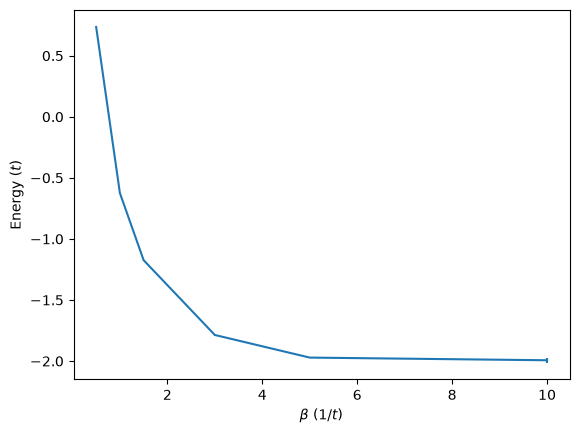

In [10]:
plt.xlabel(r'$\beta~(1/t)$')
plt.ylabel(r'Energy$~(t)$')
plt.errorbar(betas, ener[:, 0], ener[:, 1])
# plt.xlim(0, 2.02);

---
## Exercises
1. A key diagnostic in finite-temperature QMC is the crossover from a Fermi liquid to a Mott insulator as a function of temperature and interaction strength in the single-band Hubbard model. It is a well-known result ([Paiva, Scalettar, Huscroft, and McMahan, _Phys. Rev. B_ **63**, 125116 (2001)](https://doi.org/10.1103/PhysRevB.63.125116)) that the specific heat of the half-filled square lattice Hubbard model develops two distinct peaks at strong coupling: a high-temperature peak associated with the scale U, and a low-temperature peak associated with the superexchange scale J = 4t²/U. The paper presents QMC results for these thermodynamic signatures. How do these features manifest in the double occupancy, and can you resolve both peaks in the specific heat using the finite-temperature AFQMC algorithm?